STUDENT ANALYZER

STEP 1: IMPORT LIBRARIES

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression

STEP 2: EDA AND PREPROCESSING

In [24]:
df=pd.read_excel("E:\Specialization_DS\Student_analyzer\students_performance_dataset.xlsx")
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Percentage,Previous_Sem_Score,Parental_Education,Internet_Access,Family_Income,Tutoring_Classes,Sports_Activity,Extra_Curricular,School_Type,Sleep_Hours,Travel_Time,Test_Anxiety_Level,Peer_Influence,Teacher_Feedback,Motivation_Level,Library_Usage_per_Week,Final_Score
0,S1000,Male,36.330635,86.628815,38.182863,Postgraduate,No,32727.500387,No,Yes,No,Private,6.777112,2.488956,4.526416,1.698767,Good,9.416549,4,44.293533
1,S1001,Female,9.582476,73.504255,95.788249,High School,No,42332.567312,No,Yes,No,Private,6.631231,2.192993,5.920305,8.459841,Excellent,4.382245,4,42.749974
2,S1002,Male,5.795795,65.453321,73.939564,High School,Yes,44142.273093,No,No,Yes,Private,5.311059,0.887486,5.788195,4.140011,Excellent,7.373097,5,29.846049
3,S1003,Male,19.578110,94.381263,53.443393,Graduate,Yes,64498.434188,No,No,Yes,Private,6.380781,1.267095,6.313880,5.694395,Good,5.281190,6,44.030395
4,S1004,Male,39.426018,46.671849,39.749045,Postgraduate,No,42105.884774,No,No,Yes,Private,4.266327,0.397970,1.551979,8.150371,Poor,7.069597,6,42.548877


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              300 non-null    object 
 1   Gender                  300 non-null    object 
 2   Study_Hours_per_Week    300 non-null    float64
 3   Attendance_Percentage   300 non-null    float64
 4   Previous_Sem_Score      300 non-null    float64
 5   Parental_Education      300 non-null    object 
 6   Internet_Access         300 non-null    object 
 7   Family_Income           300 non-null    float64
 8   Tutoring_Classes        300 non-null    object 
 9   Sports_Activity         300 non-null    object 
 10  Extra_Curricular        300 non-null    object 
 11  School_Type             300 non-null    object 
 12  Sleep_Hours             300 non-null    float64
 13  Travel_Time             300 non-null    float64
 14  Test_Anxiety_Level      300 non-null    fl

In [26]:
df.shape

(300, 20)

In [27]:
df.isnull().sum()

Student_ID                0
Gender                    0
Study_Hours_per_Week      0
Attendance_Percentage     0
Previous_Sem_Score        0
Parental_Education        0
Internet_Access           0
Family_Income             0
Tutoring_Classes          0
Sports_Activity           0
Extra_Curricular          0
School_Type               0
Sleep_Hours               0
Travel_Time               0
Test_Anxiety_Level        0
Peer_Influence            0
Teacher_Feedback          0
Motivation_Level          0
Library_Usage_per_Week    0
Final_Score               0
dtype: int64

In [28]:
le = LabelEncoder()
df['Internet_Access']=le.fit_transform(df['Internet_Access'])
df['Tutoring_Classes']=le.fit_transform(df['Tutoring_Classes'])
df['Parental_Education']=le.fit_transform(df['Parental_Education'])
df['Sports_Activity']=le.fit_transform(df['Sports_Activity'])
df['Extra_Curricular']=le.fit_transform(df['Extra_Curricular'])
df['Teacher_Feedback']=le.fit_transform(df['Teacher_Feedback'])
df['School_Type']=le.fit_transform(df['School_Type'])
df['Gender']=le.fit_transform(df['Gender'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              300 non-null    object 
 1   Gender                  300 non-null    int64  
 2   Study_Hours_per_Week    300 non-null    float64
 3   Attendance_Percentage   300 non-null    float64
 4   Previous_Sem_Score      300 non-null    float64
 5   Parental_Education      300 non-null    int64  
 6   Internet_Access         300 non-null    int64  
 7   Family_Income           300 non-null    float64
 8   Tutoring_Classes        300 non-null    int64  
 9   Sports_Activity         300 non-null    int64  
 10  Extra_Curricular        300 non-null    int64  
 11  School_Type             300 non-null    int64  
 12  Sleep_Hours             300 non-null    float64
 13  Travel_Time             300 non-null    float64
 14  Test_Anxiety_Level      300 non-null    fl

In [29]:
exclude_cols = ['Student_ID', 'Final_Score','Extra_Curricular','School_Type','Sleep_Hours','Travel_Time','Parental_Education','Sports_Activity','Family_Income','Motivation_Level','Gender','Internet_Access','School_Type']
feature_cols = [col for col in df.columns if col not in exclude_cols]
X = df[feature_cols]

y = df['Final_Score']


len(feature_cols)

8

In [30]:
for i, col in enumerate(feature_cols, 1):
    print(f"{i:2d}. {col}")

 1. Study_Hours_per_Week
 2. Attendance_Percentage
 3. Previous_Sem_Score
 4. Tutoring_Classes
 5. Test_Anxiety_Level
 6. Peer_Influence
 7. Teacher_Feedback
 8. Library_Usage_per_Week


In [31]:
print("\nTarget Variable Statistics:")
print(f"Mean: ${y.mean():.2f}")
print(f"Median: ${y.median():.2f}")
print(f"Std Dev: ${y.std():.2f}")
print(f"Min: ${y.min():.2f}")
print(f"Max: ${y.max():.2f}")


Target Variable Statistics:
Mean: $41.45
Median: $41.60
Std Dev: $9.99
Min: $17.92
Max: $67.30


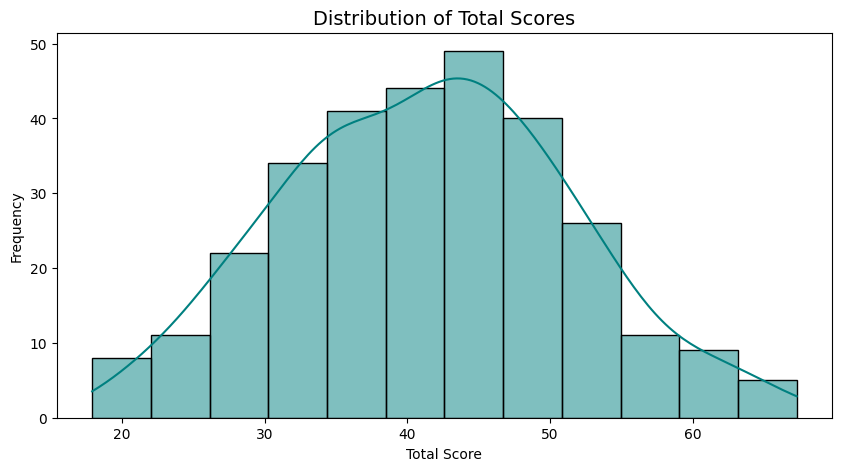

In [32]:
plt.figure(figsize=(10, 5))
sns.histplot(y, kde=True, color='teal')
plt.title("Distribution of Total Scores", fontsize=14)
plt.xlabel("Total Score")
plt.ylabel("Frequency")
plt.show()

In [33]:
print(df.columns.tolist())


['Student_ID', 'Gender', 'Study_Hours_per_Week', 'Attendance_Percentage', 'Previous_Sem_Score', 'Parental_Education', 'Internet_Access', 'Family_Income', 'Tutoring_Classes', 'Sports_Activity', 'Extra_Curricular', 'School_Type', 'Sleep_Hours', 'Travel_Time', 'Test_Anxiety_Level', 'Peer_Influence', 'Teacher_Feedback', 'Motivation_Level', 'Library_Usage_per_Week', 'Final_Score']


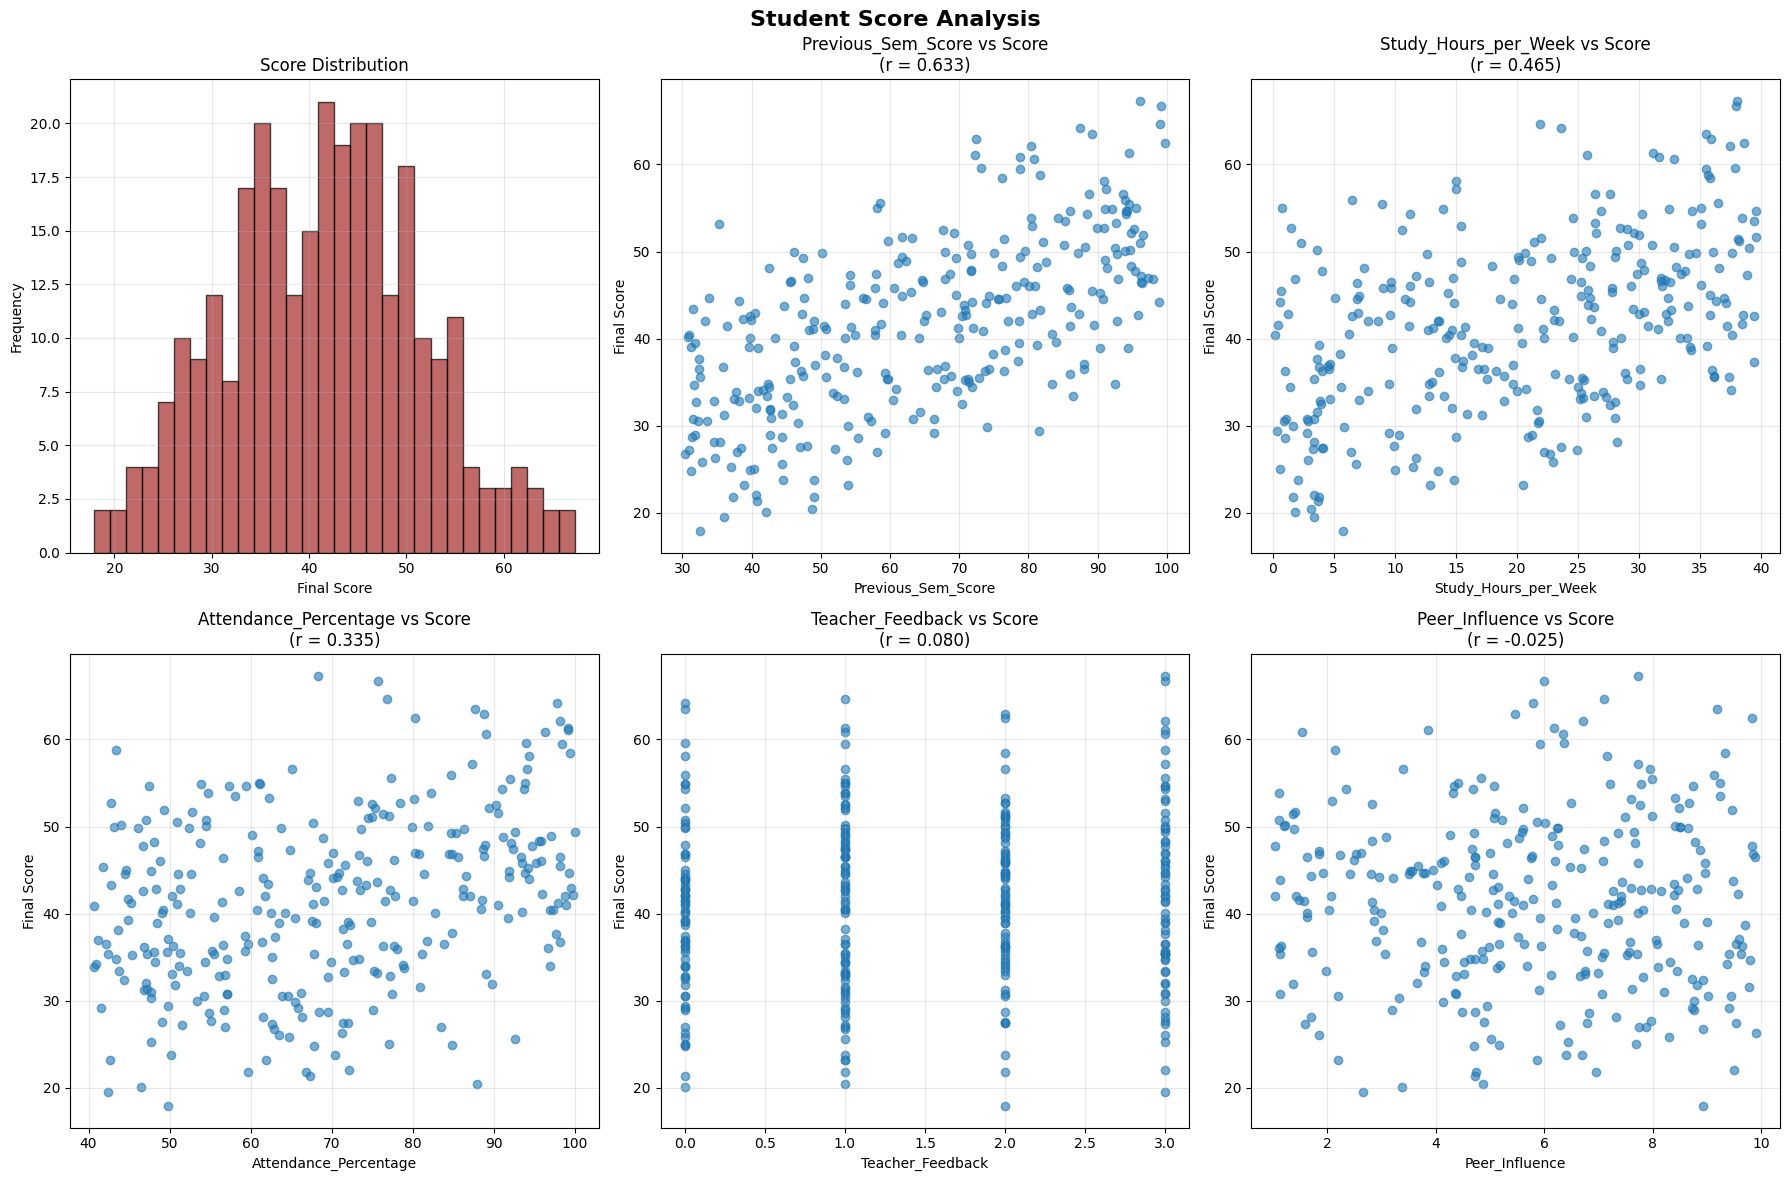

In [34]:
correlations = df[feature_cols + ['Final_Score']].corr()['Final_Score'].sort_values(ascending=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Student Score Analysis', fontsize=16, fontweight='bold')


axes[0, 0].hist(y, bins=30, alpha=0.7, color='brown', edgecolor='black')
axes[0, 0].set_title('Score Distribution')
axes[0, 0].set_xlabel('Final Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

top_features = correlations.drop('Final_Score').head(5).index

for i, feature in enumerate(top_features):
    row, col = divmod(i + 1, 3)
    axes[row, col].scatter(df[feature], y, alpha=0.6)
    axes[row, col].set_title(f'{feature} vs Score\n(r = {correlations[feature]:.3f})')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Final Score')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

SPLITTING DATA - TESTING AND TRAINING

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=None)
X_train.shape[0]

240

In [36]:
X_test.shape[0]

60

FEATURE SCALING

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled

array([[ 0.42177358, -1.06736812, -1.29421336, ...,  0.38299758,
        -0.41870217, -0.18015441],
       [-1.16784504,  0.8329788 , -1.27112942, ...,  0.85407138,
        -0.41870217,  0.18318222],
       [ 0.56844057, -1.61378556,  0.49093445, ..., -0.71030394,
         0.49482983, -1.27016429],
       ...,
       [ 1.4649556 , -1.19365911, -1.53774459, ...,  0.7216039 ,
        -1.33223416, -1.27016429],
       [ 0.97402804,  1.56122378,  0.75984116, ..., -1.76872781,
        -0.41870217,  0.90985547],
       [ 1.17626448,  0.2376555 , -0.93505459, ...,  1.5160878 ,
        -1.33223416,  1.27319209]], shape=(240, 8))

FEATURE SELECTION

In [38]:
selector = SelectKBest(score_func=f_regression, k=4)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)
selected_features = X.columns[selector.get_support()]

list(selected_features)

['Study_Hours_per_Week',
 'Attendance_Percentage',
 'Previous_Sem_Score',
 'Teacher_Feedback']

MODEL SELECTION AND TRAIN

In [39]:
model = LinearRegression()
model.fit(X_train_selected, y_train)

LinearRegression()

In [40]:
y_pred_train = model.predict(X_train_selected)
y_pred_test = model.predict(X_test_selected)

EVALUATE MODEL

In [41]:
def calculate_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Additional metrics
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n📊 {dataset_name} Set Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: ${rmse:.2f}")
    print(f"MAE: ${mae:.2f}")
    print(f"MAPE: {mape:.2f}%")

    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

In [42]:
train_metrics = calculate_metrics(y_train, y_pred_train, "Training")
test_metrics = calculate_metrics(y_test, y_pred_test, "Test")


📊 Training Set Performance:
R² Score: 0.7349
RMSE: $5.14
MAE: $4.15
MAPE: 10.89%

📊 Test Set Performance:
R² Score: 0.6299
RMSE: $5.89
MAE: $4.78
MAPE: 11.26%


In [ ]:
print(f"\n🔍 Overfitting Check:")
print(f"R² difference (Train - Test): {train_metrics['R2'] - test_metrics['R2']:.4f}")
if abs(train_metrics['R2'] - test_metrics['R2']) < 0.05:
    print("✓ Model appears to generalize well (low overfitting)")
else:
    print("⚠️ Potential overfitting detected")


🔍 Overfitting Check:
R² difference (Train - Test): 0.1049
⚠️ Potential overfitting detected


Save the model

In [ ]:
import joblib

# Save the model
joblib.dump(model, 'Student_Analyzer_t3.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save the feature selector
joblib.dump(selector, 'feature_selector.pkl')

print("✅ Model, scaler, and selector saved successfully!")

✅ Model, scaler, and selector saved successfully!
